In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

In [2]:
df=pd.read_csv('sales.csv')
df.head()

,Marketing_Spend,Store_Size,Month_Number,Competitor_Price_Index,Holiday_Flag,Sales
0,20795,302,6,0.99,0,158101
1,5860,291,2,0.91,1,87796
2,43158,84,8,1.02,1,219061
3,49732,264,8,0.86,0,299134
4,16284,386,1,1.14,1,137693


In [3]:
feature_cols= ['Marketing_Spend','Store_Size','Competitor_Price_Index']
x =df[feature_cols]

In [4]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [5]:
x_scaled

array([[-0.42935538,  0.25069994, -0.08971364],
       [-1.54374764,  0.16577972, -0.77065204],
       [ 1.23928568, -1.4322645 ,  0.16563827],
       ...,
       [ 1.26435671, -0.84554295, -1.36647315],
       [-1.35623725,  0.05769943, -0.68553474],
       [-0.70051048, -0.84554295, -1.36647315]], shape=(500, 3))

In [6]:
inertias = []
k_values = range(1, 11)
for k in k_values:
  kmeans_temp =KMeans (n_clusters=k, random_state=42)
  kmeans_temp.fit(x_scaled)
  inertias.append(kmeans_temp.inertia_)


In [7]:
inertias 

[1499.9999999999998,
 1112.2074849207238,
 899.4108724993292,
 712.2374831871916,
 585.7519524950308,
 492.2851127962527,
 425.603620181803,
 381.88492186375123,
 353.98219544429463,
 333.6740114525125]

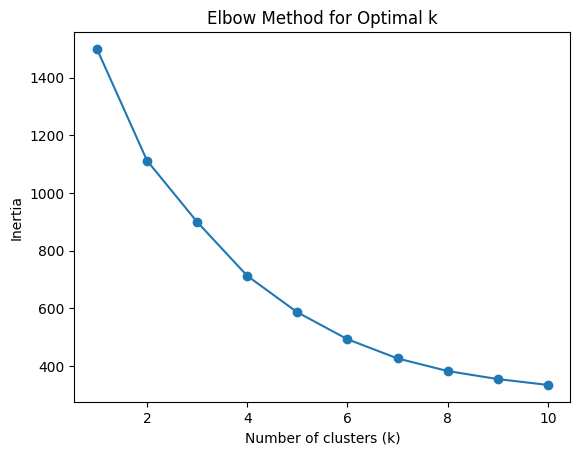

In [8]:
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [9]:
k =4 
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(x_scaled)

In [10]:
df

,Marketing_Spend,Store_Size,Month_Number,Competitor_Price_Index,Holiday_Flag,Sales,cluster
0,20795,302,6,0.99,0,158101,1
1,5860,291,2,0.91,1,87796,1
2,43158,84,8,1.02,1,219061,2
3,49732,264,8,0.86,0,299134,2
4,16284,386,1,1.14,1,137693,3
...,...,...,...,...,...,...,...
495,48404,158,7,1.20,1,253307,3
496,25491,195,8,1.10,0,163832,0
497,43494,160,6,0.84,0,268791,2
498,8373,277,6,0.92,0,87259,1


In [11]:
cluster_performance = (df.groupby('cluster')['Sales'].mean().sort_values())

In [12]:
cluster_performance

cluster
0     92655.353535
1    147042.129032
3    210868.582090
2    218216.153846
Name: Sales, dtype: float64

In [13]:
category_names =['Low_value ', 'Emerging','Core','High_value']

In [14]:
cluster_lables ={}
for i,cluster_id in enumerate(cluster_performance.index):
  cluster_lables[cluster_id] = category_names[i]

In [15]:
cluster_lables

{0: 'Low_value ', 1: 'Emerging', 3: 'Core', 2: 'High_value'}

In [16]:
df['store_category']= df['cluster'].map(cluster_lables)

In [17]:
df

,Marketing_Spend,Store_Size,Month_Number,Competitor_Price_Index,Holiday_Flag,Sales,cluster,store_category
0,20795,302,6,0.99,0,158101,1,Emerging
1,5860,291,2,0.91,1,87796,1,Emerging
2,43158,84,8,1.02,1,219061,2,High_value
3,49732,264,8,0.86,0,299134,2,High_value
4,16284,386,1,1.14,1,137693,3,Core
...,...,...,...,...,...,...,...,...
495,48404,158,7,1.20,1,253307,3,Core
496,25491,195,8,1.10,0,163832,0,Low_value
497,43494,160,6,0.84,0,268791,2,High_value
498,8373,277,6,0.92,0,87259,1,Emerging


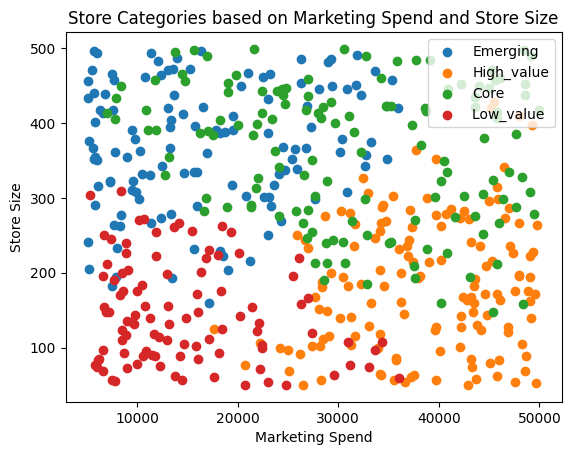

In [18]:
for category in df['store_category'].unique():
  data_category = df[df['store_category'] == category]
  plt.scatter(data_category['Marketing_Spend'], data_category['Store_Size'], label=category)
  plt.xlabel('Marketing Spend')
  plt.ylabel('Store Size')
plt.title('Store Categories based on Marketing Spend and Store Size')
plt.legend()
plt.show()

In [19]:
joblib.dump(scaler,'store_cluster_scaler.joblib')
joblib.dump(kmeans,'store_cluster_model.joblib')
joblib.dump(feature_cols,'store_cluster_features.joblib')
joblib.dump(cluster_lables,'cluster_lables.joblib')

['cluster_lables.joblib']